# Catégorisez automatiquement des questions 

## Sommaire  

- Importation des bibliothèques
- Chargement des données
- Preprrocessing for Bag of Words
    - Prétraitement des entrées et sorties
    - Transformation sur les sorties
    - Création des datasets d'entraînement et de test
- Modèles supervisés
    - Modèles BOW
        § Pipelines
        § GridsearchCV
        § Entrainement des modèles
        § Etudes des estimateurs entraînés
        § Enregistrement des estimateurs entraînés
    - Word embeddings models
            § Word2Vec
                □ Preprocessing
                □ GridsearchCV
                □ Entraînement des modèles
                □ Enregistrement des estimateurs entraînés
                □ Définition d'une méthode de transformation des données d'entrées pour une pipelie avec word2vec
            § USE
                □ Preprocessing
                □ GridsearchCV
                □ Entraînement des modèles
                □ Enregistrement des estimateurs entraînés
            § BERT
                □ 'bert-base-uncased'
                □ Preprocessing
                □ GridsearchCV
                □ Entraînement des modèles
                □ Enregistrement des estimateurs entraînés

                □ Bert spécialisé
                □ Preprocessing
                □ GridsearchCV
                □ Entraînement des modèles
                □ Enregistrement des estimateurs entraînés
- Approches non supervisées
    - LDA: Latent Dirichlet Allocation
            § Preprocessing
            § GridsearchCV
            § Entraînement des modèles
            § Etudes des estimateurs entraînés
            § Enregistrement des estimateurs entraînés
			


## *Notes: Les estimateurs présentées dans ce notebook n'ont pas tous été entraînés dans le même notebook, dans le but de paralléliser les apprentissages pour un gain de temps. De ce fait, un notebook de synthèse a été créé, dans lequel on chargera les estimateurs entraînées et les rassemblera pour une étude synthétique.  
## On ne présentera ici seulement la démarche de l'apprentissage des modèles de machine learning. L'étude intéressante est dans le notebook synthèse.


# Importation des bibliothèques 


In [20]:
# Import des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

In [2]:
# Importation des librairies pour la prédiction

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn import decomposition
# from sklearn import preprocessing
from sklearn.cluster import KMeans

from sklearn.pipeline import Pipeline
from sklearn import linear_model
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

from sklearn.metrics.cluster import adjusted_rand_score

# Visualisation des diagrammes
from sklearn import set_config


In [3]:
# # Permet d'élargir le notebook
# from IPython.core.display import display, HTML
# display(HTML("<style>.container { width:70% !important; }</style>"))

# Chargement des données

In [4]:
## Import des données brutes et analyse de leur architecture

path_local = r'D:\Utilisateurs\Damien\Documents\Test_code\test_python\OCR_projets\IML\P5_' #
# path_cloud = 

data_clean = pd.read_csv(path_local + r'\data_clean.csv',sep=",",low_memory=False)

# QueryResults
# QueryResults_2012

In [5]:
data_clean

,text_input,Tags_filtered
0,ios simulator deployment targets set range sup...,"['google', 'ios', 'xcode']"
1,rdbms partition tolerant cap theorem available...,[]
2,change connection pool size python requests mo...,"['multithreading', 'python']"
3,difference triplestores graph databasestriples...,[]
4,use public private key encryption techniquewan...,[]
...,...,...
15885,visual studio test runner discovering xunit...,"['net', 'studio', 'testing', 'unit', 'visual']"
15886,failed read artifact descriptor intellijrunnin...,"['apache', 'java', 'spark']"
15887,ctrl alt disconnects displayslearning debuggin...,"['video', 'windows']"
15888,use class customization resolve file generatin...,"['java', 'spring']"


# Preprocessing for Bag of Words  
### Prétraitement des entrées et sorties

In [6]:
data_clean['Tags_filtered']

0                            ['google', 'ios', 'xcode']
1                                                    []
2                          ['multithreading', 'python']
3                                                    []
4                                                    []
                              ...                      
15885    ['net', 'studio', 'testing', 'unit', 'visual']
15886                       ['apache', 'java', 'spark']
15887                              ['video', 'windows']
15888                                ['java', 'spring']
15889                                    ['c++', 'c++']
Name: Tags_filtered, Length: 15890, dtype: object

In [7]:
data_clean['Tags_filtered'][0]

"['google', 'ios', 'xcode']"

Après chargement des données, les cellules sous formes de listes ont été retranscrites en chaînes de caractères. On va importer la le module "ast" pour remédier à ce problème:

In [8]:
import ast
ast.literal_eval(data_clean['Tags_filtered'][0])

['google', 'ios', 'xcode']

In [9]:
data_clean['Tags_list'] = data_clean['Tags_filtered'].apply(lambda x : ast.literal_eval(x))
data_clean['Tags_list']

0                        [google, ios, xcode]
1                                          []
2                    [multithreading, python]
3                                          []
4                                          []
                         ...                 
15885    [net, studio, testing, unit, visual]
15886                   [apache, java, spark]
15887                        [video, windows]
15888                          [java, spring]
15889                              [c++, c++]
Name: Tags_list, Length: 15890, dtype: object

## Transformation sur les sorties  
On aimerait pouvoir prédire si une question est plus ou moins liée à un tag donné, mais pas juste à un seul tag. On est dans un problème de classification multilabel où la sortie peut appartenir à plusieurs labels:

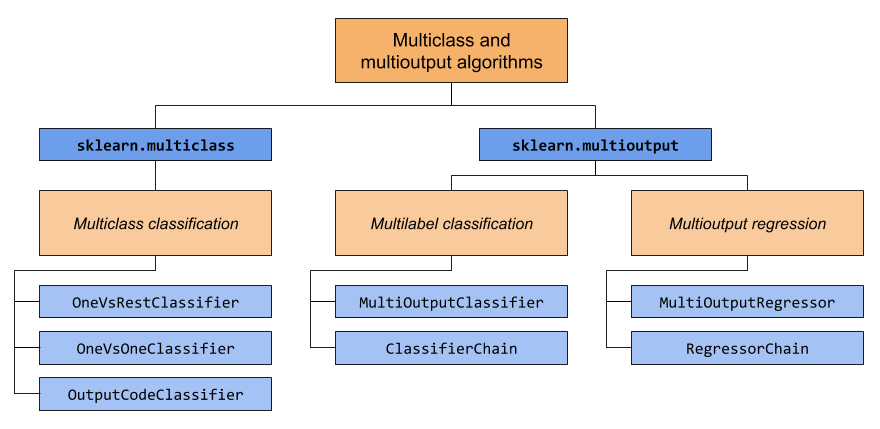

On va donc créer une colonne de sortie binaire par label, grâce à l'objet MultiLabelBinarizer de sklearn:

In [10]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

Y = mlb.fit_transform(data_clean['Tags_list'])

In [11]:
Y

array([[0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [12]:
Y.shape

(15890, 100)

In [13]:
mlb.classes_ #Y target

array(['ajax', 'algorithm', 'amazon', 'android', 'angular', 'angularjs',
       'apache', 'api', 'app', 'arrays', 'asp', 'async', 'asynchronous',
       'authentication', 'await', 'bash', 'boot', 'bootstrap', 'build',
       'c++', 'chrome', 'cocoa', 'code', 'core', 'css', 'data',
       'database', 'dataframe', 'design', 'django', 'entity', 'express',
       'file', 'framework', 'git', 'google', 'gradle', 'hibernate',
       'html', 'image', 'interface', 'ios', 'iphone', 'java',
       'javascript', 'jpa', 'jquery', 'json', 'laravel', 'layout',
       'learning', 'library', 'linux', 'machine', 'macos', 'memory',
       'multithreading', 'mvc', 'mysql', 'net', 'network', 'node',
       'numpy', 'objective', 'opencv', 'optimization', 'pandas',
       'performance', 'php', 'postgresql', 'processing', 'python',
       'rails', 'react', 'reactjs', 'rest', 'ruby', 'security', 'server',
       'services', 'shell', 'spark', 'spring', 'sql', 'ssl', 'string',
       'studio', 'swift', 'testing'

In [14]:
mlb.get_params()

{'classes': None, 'sparse_output': False}

In [15]:
import joblib

#save labels

tag_list_100 = mlb.classes_.tolist()
tag_list_100

joblib.dump(tag_list_100, 'D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\'+'tag_list_100'  + '.pkl')

['D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\tag_list_100.pkl']

## Création des datasets d'entraînement et de test

In [16]:
from sklearn import model_selection

X = data_clean['text_input']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, Y, test_size=0.2, random_state=0 ) # 20% des données dans le jeu de test # random_state = 1 pour avoir le même train-test set dans les autres jupyter notebooks

# Modèles supervisés
## Modèles BOW
On va transformer les sorties avec l'approche "Bag of Words" où "Sac de mots", dans laquelle on contera la fréquence d'apparition de chaque caractère par phrases (countvectorizer) et une autre ou la fréquence de chaques mots sera pénalisée par rapport à son nombre (TfidfVectorizer).  

### Pipelines

In [17]:
# création du bag of words (CountVectorizer et Tf-idf)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# token_pattern = '[a-zA-Z0-9$&+,:;=?@#|<>.^*()%!-]+' # pour garder les caractères spéciaux comme #, @, ...

cvect_input = CountVectorizer( )
tfidf_input = TfidfVectorizer()


In [19]:

from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# # Pipelines pour CountVectorizer

# pipe_rc = Pipeline(steps =[('cvect_input', cvect_input),('model_rc', MultiOutputClassifier(RidgeClassifier()) )])
# pipe_rf = Pipeline(steps =[('cvect_input', cvect_input),('model_rf', MultiOutputClassifier(RandomForestClassifier()) )])
# pipe_pac = Pipeline(steps =[('cvect_input', cvect_input),('model_pac', MultiOutputClassifier(linear_model.PassiveAggressiveClassifier()))])


In [20]:
# Pipelines pour TF-IDF

pipe_rc = Pipeline(steps =[('tfidf_input', tfidf_input),('model_rc', MultiOutputClassifier(RidgeClassifier()) )])
pipe_rf = Pipeline(steps =[('tfidf_input', tfidf_input),('model_rf', MultiOutputClassifier(RandomForestClassifier()) )])
pipe_pac = Pipeline(steps =[('tfidf_input', tfidf_input),('model_pac', MultiOutputClassifier(linear_model.PassiveAggressiveClassifier()))])

In [21]:
# Visualisation par diagrammes
set_config(display="diagram")

### GridSearchCV: Validation croisée

Exemples de paramètres modifiables:

In [22]:
pipe_rc['model_rc'].get_params().keys()

dict_keys(['estimator__alpha', 'estimator__class_weight', 'estimator__copy_X', 'estimator__fit_intercept', 'estimator__max_iter', 'estimator__normalize', 'estimator__positive', 'estimator__random_state', 'estimator__solver', 'estimator__tol', 'estimator', 'n_jobs'])

In [23]:
pipe_rc.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'tfidf_input', 'model_rc', 'tfidf_input__analyzer', 'tfidf_input__binary', 'tfidf_input__decode_error', 'tfidf_input__dtype', 'tfidf_input__encoding', 'tfidf_input__input', 'tfidf_input__lowercase', 'tfidf_input__max_df', 'tfidf_input__max_features', 'tfidf_input__min_df', 'tfidf_input__ngram_range', 'tfidf_input__norm', 'tfidf_input__preprocessor', 'tfidf_input__smooth_idf', 'tfidf_input__stop_words', 'tfidf_input__strip_accents', 'tfidf_input__sublinear_tf', 'tfidf_input__token_pattern', 'tfidf_input__tokenizer', 'tfidf_input__use_idf', 'tfidf_input__vocabulary', 'model_rc__estimator__alpha', 'model_rc__estimator__class_weight', 'model_rc__estimator__copy_X', 'model_rc__estimator__fit_intercept', 'model_rc__estimator__max_iter', 'model_rc__estimator__normalize', 'model_rc__estimator__positive', 'model_rc__estimator__random_state', 'model_rc__estimator__solver', 'model_rc__estimator__tol', 'model_rc__estimator', 'model_rc__n_jobs'])

Choix de la grille d'hyperparamètre qui sera testé par chaque modèle.

In [77]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn import metrics
# -------------- pipelines parameters

n_folds = 5
verbose_gd = 2

# cvect_input - tfidf_input

max_df_range = [0.3, 0.5, 0.9]
min_df_range = [1,5,10]

# RC
c_range = np.linspace(0.1,1,4)
alpha_range = 1/(2*c_range)

# RF
max_depth_range = list(range(1,20))
# min_samples_leaf_range = list(range(1,10))

#PAC
# max_iter_range = list(range(10,1200,200))
c_range = np.linspace(0.1,1,4) 

# -------------- param_grid for pipelines 


# -------------- param_grid of estimators 

grid_rc = {      'model_rc__estimator__alpha': alpha_range }
grid_rf =  {} #   'model_rf__estimator__min_samples_leaf':min_samples_leaf_range }
grid_pac =  {'model_pac__estimator__C':c_range } # 'model_pac__estimator__max_iter': max_iter_range, 

grid_cvect = {'cvect_input__max_df': max_df_range, 'cvect_input__min_df': min_df_range}
grid_tfidf = {'tfidf_input__max_df': max_df_range, 'tfidf_input__min_df': min_df_range}



# -------------- param_grid of estimators for countvectorizer method 

# parameters_rc = dict(grid_cvect, **grid_rc)
# parameters_rf = dict(grid_cvect, **grid_rf)
# parameters_pac = dict(grid_cvect, **grid_pac)

# -------------- param_grid of estimators for tfidf_input method 

parameters_rc = dict(grid_tfidf, **grid_rc)
parameters_rf = dict(grid_tfidf, **grid_rf)
parameters_pac = dict(grid_tfidf, **grid_pac)



On va utiliser la métrique de score "Jaccard" dans notre problème:

In [25]:
sorted(metrics.SCORERS.keys())

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'max_error',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_root_mean_squared_error',
 'normalized_mutual_info_score',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 'recall_macro',
 'recall_micro',
 'recall_samples',
 'recall_weighted',
 'roc_auc',
 'roc_auc_ovo',
 'roc_auc_ovo_weighted',
 'roc_auc_ovr',
 'roc_auc_ovr_we

Pour s'asssurer que notre métrique nous renvoie un scalaire et non un vecteur pour chaque tags de notre sortie Y, on va utiliser le paramètre average='samples'. Pour éviter les warnings ou erreurs dans un cas où il y aurait une division par zéro, on choisit l'option de résultat zero_division=0.

In [79]:
from sklearn.metrics import jaccard_score
# -------------- Define scoring functions
def jaccard_func(y_true, y_pred):
    result_score = jaccard_score(y_true, y_pred, average='samples',zero_division=0)
    return result_score

# -------------- Score and error functions
score_jaccard_func = make_scorer(jaccard_func, greater_is_better=True)
scoring_model = {'score_jaccard_func':score_jaccard_func, 'accuracy':'accuracy'}


Exemple d'erreur de division par zéro à éviter:  

C:\Users\daims\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 in samples with no true or predicted labels. Use `zero_division` parameter to control this behavior.  

### Entraînement des modèles  
ici, on crée nos modèles de gridsearchCV que l'on va entraîner:

In [28]:
# -------------- GridsearchCV declaration

pipe_rc_cv = GridSearchCV(pipe_rc, parameters_rc,return_train_score=True, cv=n_folds,verbose = verbose_gd, scoring = scoring_model,refit='score_jaccard_func')
pipe_rf_cv = GridSearchCV(pipe_rf, parameters_rf,return_train_score=True, cv=n_folds,verbose = verbose_gd, scoring = scoring_model,refit='score_jaccard_func')
pipe_pac_cv = GridSearchCV(pipe_pac, parameters_pac,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')


In [142]:
# pipe_lr_cv.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=1, model_lr__estimator__C=0.1, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 4.8min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=1, model_lr__estimator__C=0.1, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 4.5min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=1, model_lr__estimator__C=0.1, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 4.8min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=1, model_lr__estimator__C=0.1, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 5.2min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=1, model_lr_

[CV] END cvect_input__max_df=0.3, cvect_input__min_df=5, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 3.3min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=5, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 3.2min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=10, model_lr__estimator__C=0.1, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 2.2min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=10, model_lr__estimator__C=0.1, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 2.1min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=10, model_lr__estimator__C=0.1, model_lr__estimator__max_iter=500, model

[CV] END cvect_input__max_df=0.5, cvect_input__min_df=1, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 6.7min
[CV] END cvect_input__max_df=0.5, cvect_input__min_df=1, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 7.0min
[CV] END cvect_input__max_df=0.5, cvect_input__min_df=1, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 6.6min
[CV] END cvect_input__max_df=0.5, cvect_input__min_df=1, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 6.9min
[CV] END cvect_input__max_df=0.5, cvect_input__min_df=5, model_lr__estimator__C=0.1, model_lr__estimator__max_iter=500, model_lr

[CV] END cvect_input__max_df=0.5, cvect_input__min_df=10, model_lr__estimator__C=0.7, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 3.4min
[CV] END cvect_input__max_df=0.5, cvect_input__min_df=10, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 3.6min
[CV] END cvect_input__max_df=0.5, cvect_input__min_df=10, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 3.4min
[CV] END cvect_input__max_df=0.5, cvect_input__min_df=10, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 3.7min
[CV] END cvect_input__max_df=0.5, cvect_input__min_df=10, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, mod

[CV] END cvect_input__max_df=0.9, cvect_input__min_df=5, model_lr__estimator__C=0.7, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 5.2min
[CV] END cvect_input__max_df=0.9, cvect_input__min_df=5, model_lr__estimator__C=0.7, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 5.3min
[CV] END cvect_input__max_df=0.9, cvect_input__min_df=5, model_lr__estimator__C=0.7, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 4.9min
[CV] END cvect_input__max_df=0.9, cvect_input__min_df=5, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr__estimator__multi_class=multinomial, model_lr__estimator__penalty=l2; total time= 5.1min
[CV] END cvect_input__max_df=0.9, cvect_input__min_df=5, model_lr__estimator__C=1.0, model_lr__estimator__max_iter=500, model_lr

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('cvect_input', CountVectorizer()),
                                       ('model_lr',
                                        MultiOutputClassifier(estimator=LogisticRegression()))]),
             param_grid={'cvect_input__max_df': [0.3, 0.5, 0.9],
                         'cvect_input__min_df': [1, 5, 10],
                         'model_lr__estimator__C': array([0.1, 0.4, 0.7, 1. ]),
                         'model_lr__estimator__max_iter': [500],
                         'model_lr__estimator__multi_class': ['multinomial'],
                         'model_lr__estimator__penalty': ['l2']},
             refit='score_jaccard_func', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'score_jaccard_func': make_scorer(jaccard_func)},
             verbose=2)

In [128]:
pipe_rf_cv.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.1; total time= 4.2min
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.1; total time= 4.2min
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.1; total time= 4.3min
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.1; total time= 4.3min
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.1; total time= 4.3min
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.2; total time= 3.1min
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.2; total time= 3.1min
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.2; total time= 3.1min
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.2; total time= 3.1min
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.2; total time= 3.1min
[CV] END ...cvect_input__max_df=0.4, cvect_input__min_df=0.3; total time= 2.0min
[CV] END ...cvect_input__max_df=0.4, cvect_input_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('cvect_input', CountVectorizer()),
                                       ('model_rf',
                                        MultiOutputClassifier(estimator=RandomForestClassifier()))]),
             param_grid={'cvect_input__max_df': [0.4, 0.6, 0.9],
                         'cvect_input__min_df': [0.1, 0.2, 0.3]},
             refit='score_jaccard_func', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'score_jaccard_func': make_scorer(jaccard_func)},
             verbose=2)

In [29]:
pipe_pac_cv.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END model_pac__estimator__C=0.1, tfidf_input__max_df=0.3, tfidf_input__min_df=1; total time=   6.3s
[CV] END model_pac__estimator__C=0.1, tfidf_input__max_df=0.3, tfidf_input__min_df=1; total time=   6.5s
[CV] END model_pac__estimator__C=0.1, tfidf_input__max_df=0.3, tfidf_input__min_df=1; total time=   6.3s
[CV] END model_pac__estimator__C=0.1, tfidf_input__max_df=0.3, tfidf_input__min_df=1; total time=   6.3s
[CV] END model_pac__estimator__C=0.1, tfidf_input__max_df=0.3, tfidf_input__min_df=1; total time=   6.4s
[CV] END model_pac__estimator__C=0.1, tfidf_input__max_df=0.3, tfidf_input__min_df=5; total time=   4.7s
[CV] END model_pac__estimator__C=0.1, tfidf_input__max_df=0.3, tfidf_input__min_df=5; total time=   4.6s
[CV] END model_pac__estimator__C=0.1, tfidf_input__max_df=0.3, tfidf_input__min_df=5; total time=   4.7s
[CV] END model_pac__estimator__C=0.1, tfidf_input__max_df=0.3, tfidf_input__min_df=5; total time= 

[CV] END model_pac__estimator__C=0.4, tfidf_input__max_df=0.9, tfidf_input__min_df=1; total time=   5.3s
[CV] END model_pac__estimator__C=0.4, tfidf_input__max_df=0.9, tfidf_input__min_df=1; total time=   5.3s
[CV] END model_pac__estimator__C=0.4, tfidf_input__max_df=0.9, tfidf_input__min_df=5; total time=   4.5s
[CV] END model_pac__estimator__C=0.4, tfidf_input__max_df=0.9, tfidf_input__min_df=5; total time=   4.5s
[CV] END model_pac__estimator__C=0.4, tfidf_input__max_df=0.9, tfidf_input__min_df=5; total time=   4.5s
[CV] END model_pac__estimator__C=0.4, tfidf_input__max_df=0.9, tfidf_input__min_df=5; total time=   4.5s
[CV] END model_pac__estimator__C=0.4, tfidf_input__max_df=0.9, tfidf_input__min_df=5; total time=   4.5s
[CV] END model_pac__estimator__C=0.4, tfidf_input__max_df=0.9, tfidf_input__min_df=10; total time=   4.4s
[CV] END model_pac__estimator__C=0.4, tfidf_input__max_df=0.9, tfidf_input__min_df=10; total time=   4.3s
[CV] END model_pac__estimator__C=0.4, tfidf_input__ma

[CV] END model_pac__estimator__C=1.0, tfidf_input__max_df=0.5, tfidf_input__min_df=5; total time=   3.9s
[CV] END model_pac__estimator__C=1.0, tfidf_input__max_df=0.5, tfidf_input__min_df=5; total time=   4.0s
[CV] END model_pac__estimator__C=1.0, tfidf_input__max_df=0.5, tfidf_input__min_df=5; total time=   4.1s
[CV] END model_pac__estimator__C=1.0, tfidf_input__max_df=0.5, tfidf_input__min_df=5; total time=   4.3s
[CV] END model_pac__estimator__C=1.0, tfidf_input__max_df=0.5, tfidf_input__min_df=10; total time=   4.2s
[CV] END model_pac__estimator__C=1.0, tfidf_input__max_df=0.5, tfidf_input__min_df=10; total time=   4.2s
[CV] END model_pac__estimator__C=1.0, tfidf_input__max_df=0.5, tfidf_input__min_df=10; total time=   4.2s
[CV] END model_pac__estimator__C=1.0, tfidf_input__max_df=0.5, tfidf_input__min_df=10; total time=   4.1s
[CV] END model_pac__estimator__C=1.0, tfidf_input__max_df=0.5, tfidf_input__min_df=10; total time=   4.2s
[CV] END model_pac__estimator__C=1.0, tfidf_input_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf_input', TfidfVectorizer()),
                                       ('model_pac',
                                        MultiOutputClassifier(estimator=PassiveAggressiveClassifier()))]),
             param_grid={'model_pac__estimator__C': array([0.1, 0.4, 0.7, 1. ]),
                         'tfidf_input__max_df': [0.3, 0.5, 0.9],
                         'tfidf_input__min_df': [1, 5, 10]},
             refit='score_jaccard_func', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'score_jaccard_func': make_scorer(jaccard_func)},
             verbose=2)

### Etudes des estimateurs entraînés

In [125]:
pipe_rf_cv.best_params_

{'model_rf__estimator__max_depth': 19}

In [30]:
pipe_pac_cv.best_score_

0.48118070784454686

In [134]:
pd.DataFrame(pipe_rf_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_cvect_input__max_df,param_cvect_input__min_df,params,split0_test_score_jaccard_func,split1_test_score_jaccard_func,split2_test_score_jaccard_func,...,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_train_accuracy,split1_train_accuracy,split2_train_accuracy,split3_train_accuracy,split4_train_accuracy,mean_train_accuracy,std_train_accuracy
0,247.606952,1.164853,7.338862,0.362496,0.4,0.1,"{'cvect_input__max_df': 0.4, 'cvect_input__min...",0.016090,0.016588,0.014477,...,0.062382,0.001237,3,0.982791,0.983873,0.981514,0.981908,0.983677,0.982753,0.000934
1,177.611394,0.684231,7.001413,0.282095,0.4,0.2,"{'cvect_input__max_df': 0.4, 'cvect_input__min...",0.007495,0.008157,0.008438,...,0.055302,0.003176,4,0.461697,0.467204,0.459784,0.460865,0.463815,0.462673,0.002623
2,116.459134,3.538477,5.540969,0.204301,0.4,0.3,"{'cvect_input__max_df': 0.4, 'cvect_input__min...",0.002963,0.004027,0.003023,...,0.054594,0.002327,5,0.171010,0.168846,0.168043,0.168338,0.168142,0.168876,0.001102
3,269.839900,12.492928,7.924718,0.540321,0.6,0.1,"{'cvect_input__max_df': 0.6, 'cvect_input__min...",0.014091,0.016595,0.013949,...,0.063090,0.001826,1,0.985446,0.985544,0.983284,0.981416,0.985152,0.984169,0.001603
4,213.524433,1.797388,9.075706,0.452350,0.6,0.2,"{'cvect_input__max_df': 0.6, 'cvect_input__min...",0.006483,0.007122,0.006799,...,0.053178,0.003390,8,0.547841,0.549513,0.549361,0.549164,0.553392,0.549854,0.001866
5,162.255776,15.660118,6.426724,0.226801,0.6,0.3,"{'cvect_input__max_df': 0.6, 'cvect_input__min...",0.004821,0.004962,0.004446,...,0.054201,0.002546,6,0.250369,0.248500,0.248181,0.245526,0.247591,0.248033,0.001561
6,262.102270,2.472308,7.938670,0.392152,0.9,0.1,"{'cvect_input__max_df': 0.9, 'cvect_input__min...",0.015140,0.014491,0.014140,...,0.062697,0.001137,2,0.985446,0.985249,0.984464,0.982891,0.985054,0.984621,0.000925
7,199.569332,7.136854,8.910328,0.682895,0.9,0.2,"{'cvect_input__max_df': 0.9, 'cvect_input__min...",0.005684,0.007515,0.007068,...,0.053100,0.002948,9,0.548628,0.551185,0.549164,0.548574,0.554769,0.550464,0.002353
8,141.129611,1.052779,6.407193,0.247425,0.9,0.3,"{'cvect_input__max_df': 0.9, 'cvect_input__min...",0.004172,0.005211,0.004295,...,0.053808,0.002134,7,0.251352,0.248894,0.248968,0.244838,0.247493,0.248309,0.002133


In [ ]:
def plot_results(estimator,estimator_name):
    plt.figure(figsize=(18,14))
    #plt.suptitle(str(f'{estimator=}'.split('=')[0]))
    plt.suptitle(estimator_name, fontsize=20)
    ax = plt.gca()

    plt.subplot(3,1,1)
    plt.plot(list(range(len(estimator.cv_results_['mean_train_score'].data))), estimator.cv_results_['mean_train_score'])
    plt.plot(list(range(len(estimator.cv_results_['mean_test_score'].data))), estimator.cv_results_['mean_test_score'])
    plt.legend(['mean_train_score','mean_test_score'])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')
    
    plt.subplot(3,1,2)
    plt.plot(list(range(len(estimator.cv_results_['std_train_score'].data))), estimator.cv_results_['std_train_score'])
    plt.plot(list(range(len(estimator.cv_results_['std_test_score'].data))), estimator.cv_results_['std_test_score'])
    plt.legend(['std_train_score','std_test_score'])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')

    plt.subplot(3,1,3)
    plt.plot(list(range(len(estimator.cv_results_['mean_train_score'].data))), estimator.cv_results_['mean_fit_time'])
    plt.legend(['mean_fit_time'])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')
    
    # plt.axis('tight')
    plt.show()


In [ ]:
def plot_results2(estimator,estimator_name,score_name):
    plt.figure(figsize=(18,14))
    #plt.suptitle(str(f'{estimator=}'.split('=')[0]))
    plt.suptitle(estimator_name, fontsize=20)
    ax = plt.gca()
    
    mean_train = 'mean_train_' + score_name
    mean_test = 'mean_test_' + score_name
    std_train = 'std_train_' + score_name
    std_test =  'std_test_' + score_name
    
    plt.subplot(3,1,1)
    plt.plot(list(range(len(estimator.cv_results_[mean_train].data))), estimator.cv_results_[mean_train])
    plt.plot(list(range(len(estimator.cv_results_[mean_test].data))), estimator.cv_results_[mean_test])
    plt.legend([mean_train,mean_test])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')
    
    plt.subplot(3,1,2)
    plt.plot(list(range(len(estimator.cv_results_[std_train].data))), estimator.cv_results_[std_train])
    plt.plot(list(range(len(estimator.cv_results_[std_test].data))), estimator.cv_results_[std_test])
    plt.legend([std_train,std_test])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')

    plt.subplot(3,1,3)
    plt.plot(list(range(len(estimator.cv_results_['mean_fit_time'].data))), estimator.cv_results_['mean_fit_time'])
    plt.legend(['mean_fit_time'])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')
    
    # plt.axis('tight')
    plt.show()


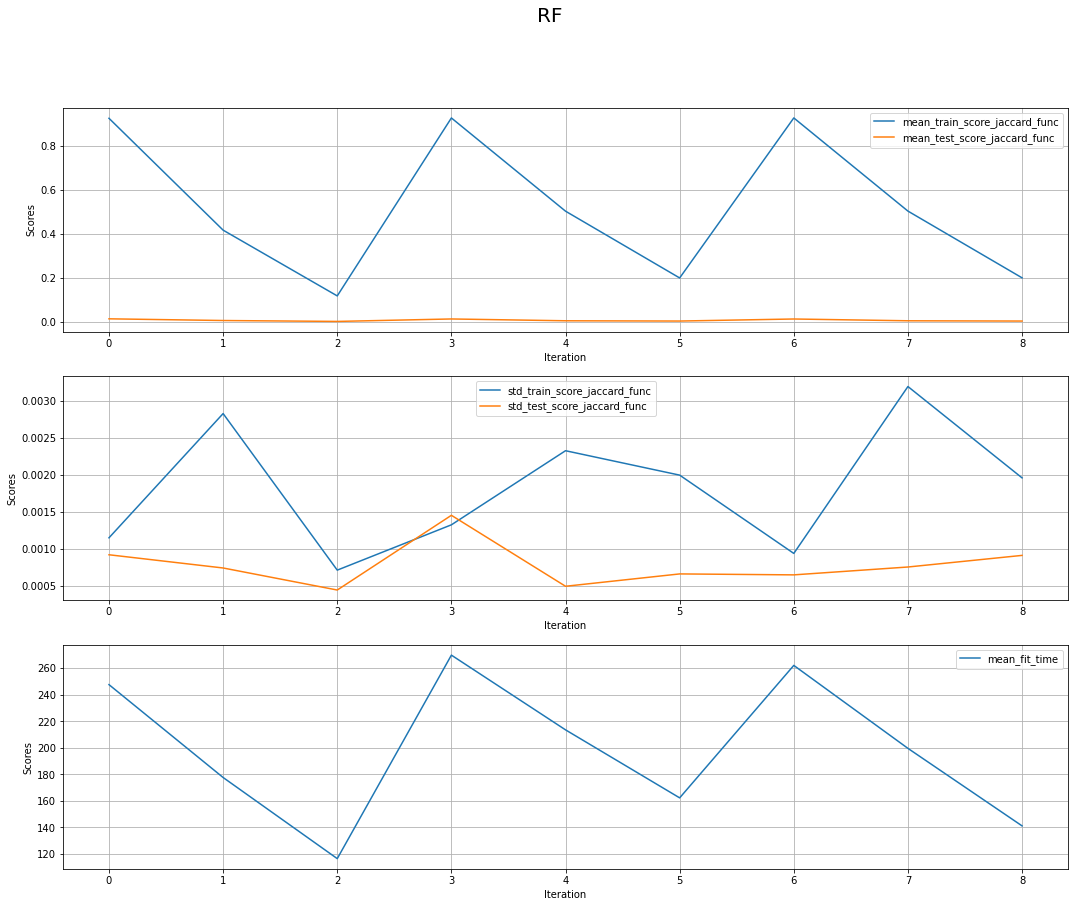

In [129]:
plot_results2(pipe_rf_cv,'RF','score_jaccard_func')

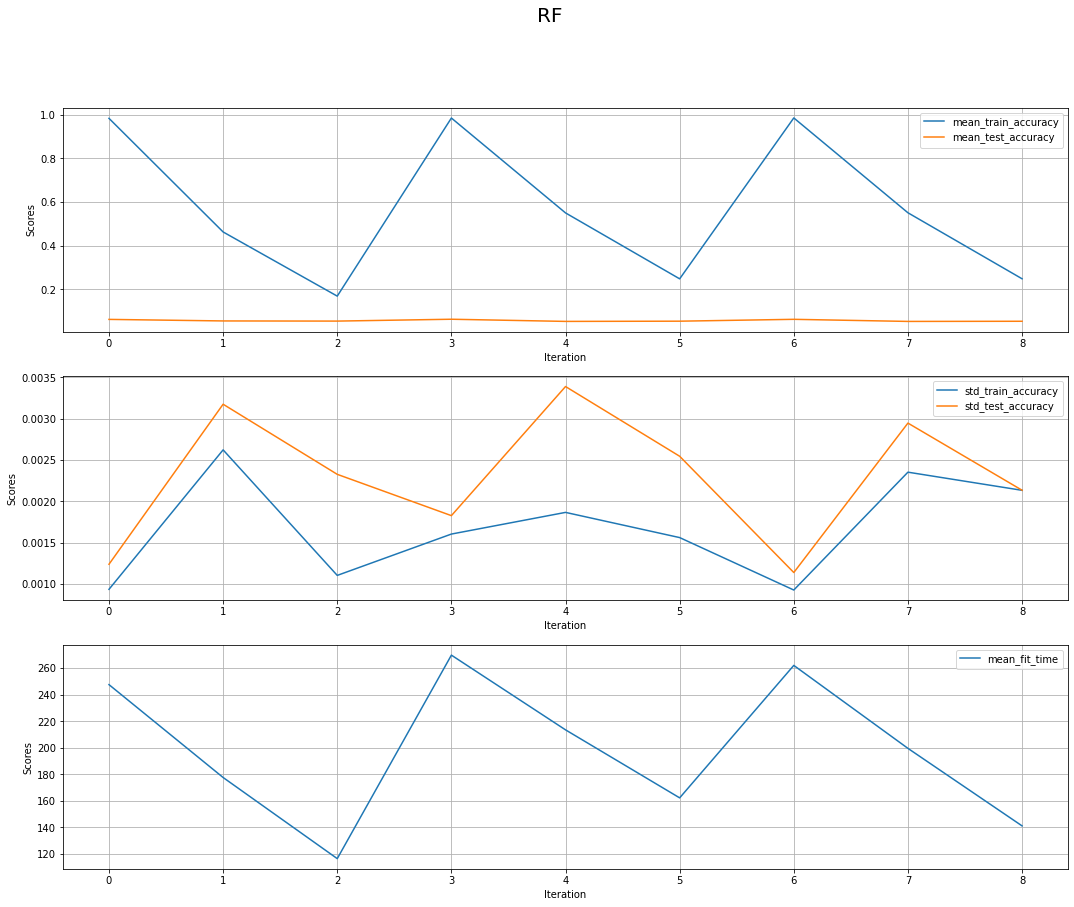

In [130]:
plot_results2(pipe_rf_cv,'RF','accuracy')

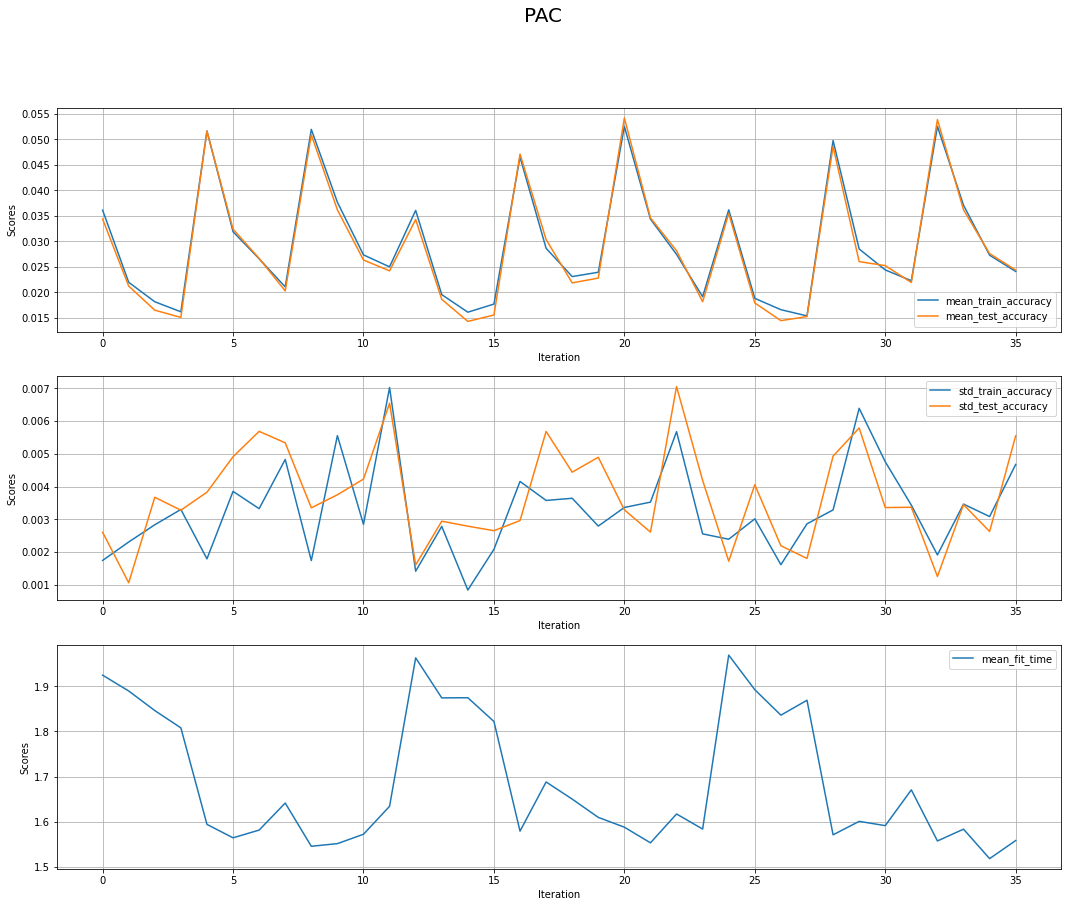

In [133]:
plot_results2(pipe_pac_cv,'PAC','accuracy')

### Enregistrement des estimateurs entraînés

On choisit d'enregistrer toout les modèles entraînés grâce au module joblib, pour effectuer une synthèse des scores de tout nos différents modèles utilisés par la suite dans un notebook à part.

In [31]:
import joblib

#save your model or results

joblib.dump(pipe_pac_cv, 'D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\'+'tfidf_input_' + 'pipe_pac_cv'  + '.pkl')

['D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\tfidf_input_pipe_pac_cv.pkl']

## Word embeddings models  
On décide d'utiliser d'autres approches de transformations des entrées que l'on donne à nos estimateurs, et qui sont différentes des bags of words, notamment par une approche plus sémantique de la compréhension du langage.
En particulier, on va s'intéresser rapidement à:
- Word2Vec: Words to vectors
- USE : Universal Sentence Encoder
- BERT: Bidirectional Encoder Representations from Transformers

In [64]:
# Import des librairies
import nltk
import pickle
import time
from sklearn import cluster, metrics
from sklearn import manifold, decomposition
import logging

logging.disable(logging.WARNING) # disable WARNING, INFO and DEBUG logging everywhere


In [65]:
import time

# Calcul Tsne, détermination des clusters et calcul ARI entre vrais catégorie et n° de clusters
def ARI_fct(features,num_labels,y_cat_num) :
    time1 = time.time()
#     num_labels=len(l_cat)
    tsne = manifold.TSNE(n_components=2, perplexity=30, n_iter=2000, 
                                 init='random', learning_rate=200, random_state=42)
    X_tsne = tsne.fit_transform(features)
    
    # Détermination des clusters à partir des données après Tsne 
    cls = cluster.KMeans(n_clusters=num_labels, n_init=100, random_state=42)
    cls.fit(X_tsne)
    ARI = np.round(metrics.adjusted_rand_score(y_cat_num, cls.labels_),4)
    time2 = np.round(time.time() - time1,0)
    print("ARI : ", ARI, "time : ", time2)
    
    return ARI, X_tsne, cls.labels_


# visualisation du Tsne selon les vraies catégories et selon les clusters
def TSNE_visu_fct(X_tsne, y_cat_num, labels, ARI) :
    fig = plt.figure(figsize=(15,6))
    
    ax = fig.add_subplot(121)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=y_cat_num, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=l_cat, loc="best", title="Categorie")
    plt.title('Représentation des tweets par catégories réelles')
    
    ax = fig.add_subplot(122)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=labels, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(labels), loc="best", title="Clusters")
    plt.title('Représentation des tweets par clusters')
    
    plt.show()
    print("ARI : ", ARI)


### Word2Vec  
#### Preprocessing

In [62]:
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras import backend as K

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import metrics as kmetrics
from tensorflow.keras.layers import *

from tensorflow.keras.models import Model
import gensim

C:\Users\daims\anaconda3\lib\site-packages\tensorflow\core\framework\tensor_shape_pb2.py:18: DeprecationWarning: Call to deprecated create function FileDescriptor(). Note: Create unlinked descriptors is going to go away. Please use get/find descriptors from generated code or query the descriptor_pool.
  DESCRIPTOR = _descriptor.FileDescriptor(
C:\Users\daims\anaconda3\lib\site-packages\tensorflow\core\framework\tensor_shape_pb2.py:36: DeprecationWarning: Call to deprecated create function FieldDescriptor(). Note: Create unlinked descriptors is going to go away. Please use get/find descriptors from generated code or query the descriptor_pool.
  _descriptor.FieldDescriptor(
C:\Users\daims\anaconda3\lib\site-packages\tensorflow\core\framework\tensor_shape_pb2.py:43: DeprecationWarning: Call to deprecated create function FieldDescriptor(). Note: Create unlinked descriptors is going to go away. Please use get/find descriptors from generated code or query the descriptor_pool.
  _descriptor.F

C:\Users\daims\anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:513: DeprecationWarning: `np.object` is a deprecated alias for the builtin `object`. To silence this warning, use `object` by itself. Doing this will not modify any behavior and is safe. 
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  np.object,
C:\Users\daims\anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  np.bool,
C:\Users\daims\anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:555: DeprecationWarning: `np.object` is a depreca

On choisit de manière arbitraire la taille de nos vecteurs finaux avec le paramètre w2v_size. plus il sera grand, plus la description d'un mot ou d'une phase sera nuancée ou sémantiquement intéressante, mais plus le calcul sera gourmand.  
On choisit de manière arbitraire la taille de la fenêtre de contexte "w2v_window" utilisé autour chaque mot durant l'entraînement.  


In [ ]:
# Création du modèle Word2Vec

w2v_size=300
w2v_window=5
w2v_min_count=1
w2v_epochs=100
maxlen = 24 # adapt to length of sentences
sentences = data_clean['text_input'].to_list()
sentences = [gensim.utils.simple_preprocess(text) for text in sentences]


In [ ]:
# Création et entraînement du modèle Word2Vec

print("Build & train Word2Vec model ...")
w2v_model = gensim.models.Word2Vec(min_count=w2v_min_count, window=w2v_window,
                                                vector_size=w2v_size,
                                                seed=42,
                                                workers=1)
#                                                workers=multiprocessing.cpu_count())
w2v_model.build_vocab(sentences)
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=w2v_epochs)
model_vectors = w2v_model.wv
w2v_words = model_vectors.index_to_key
print("Vocabulary size: %i" % len(w2v_words))
print("Word2Vec trained")

In [ ]:
model_vectors.vectors.shape

Chaque mot est représenté par un vecteur de taille w2v_size = 300. La matrice de ces vecteurs est contenue dans "model_vectors.vectors".

In [ ]:
# Préparation des sentences (tokenization)

print("Fit Tokenizer ...")
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
x_sentences = pad_sequences(tokenizer.texts_to_sequences(sentences),
                                                     maxlen=maxlen,
                                                     padding='post') 
                                                   
num_words = len(tokenizer.word_index) + 1
print("Number of unique words: %i" % num_words)

On a récupéré le vocabulaire des mots uniques employés dans les phrases (sentences sous forme de liste).

In [ ]:
# Création de la matrice d'embedding

print("Create Embedding matrix ...")
w2v_size = 300
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
embedding_matrix = np.zeros((vocab_size, w2v_size))
i=0
j=0
    
for word, idx in word_index.items():
    i +=1
    if word in w2v_words:
        j +=1
        embedding_vector = model_vectors[word]
        if embedding_vector is not None:
            embedding_matrix[idx] = model_vectors[word]
            
word_rate = np.round(j/i,4)
print("Word embedding rate : ", word_rate)
print("Embedding matrix: %s" % str(embedding_matrix.shape))

In [ ]:
embedding_matrix.shape
#Chaque mot (parmis les 72578) est un vecteur de 300 coordonnées. 
#Il faut réussir à retranscrire les 15890 sentences. 

On a récupéré les poids associés aux vecteurs de chaque mots, et on s'est assuré que les mots dont on veut réaliser la matrice d'embedding sont bien dans le modèle des mots dont on a les vecteurs de poids.

In [ ]:
# Création du modèle d'embedding

input=Input(shape=(len(x_sentences),maxlen),dtype='float64')
word_input=Input(shape=(maxlen,),dtype='float64')  
word_embedding=Embedding(input_dim=vocab_size,
                         output_dim=w2v_size,
                         weights = [embedding_matrix],
                         input_length=maxlen)(word_input)
word_vec=GlobalAveragePooling1D()(word_embedding)  
embed_model = Model([word_input],word_vec)

embed_model.summary()

On utilise ensuite des outils de la librarie de TensorFlow pour reconstruire des vecteurs de phrases à partir des mots dont chaque phrase est composée. Une moyenne des mots de la phrase peut, par exemple, être utilisée.

#### Exécution du modèle  
On éxécute le modèle créé par TensorFlow pour obtenir notre matrice d'embeddings des phrases grâce à la prédiction des moyennes de l'opération du modèle GlobalAveragePooling1D.

In [ ]:
embeddings = embed_model.predict(x_sentences)
embeddings.shape

In [ ]:
# num_labels = list(freq_tags)[0:100]
# y_cat_num = Y
# ARI, X_tsne, labels = ARI_fct(embeddings,num_labels,y_cat_num)

In [ ]:
# TSNE_visu_fct(X_tsne, y_cat_num, labels, ARI)

In [ ]:
from sklearn import model_selection

X = embeddings #embedding_matrix

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, Y, test_size=0.2, random_state=0 ) # 20% des données dans le jeu de test # random_state = 1 pour avoir le même train-test set dans les autres jupyter notebooks

#### GridsearchCV

In [ ]:
# --------- Grid Parameters

grid_rc = {      'estimator__alpha': alpha_range }
grid_rf =  {} #'estimator__min_samples_leaf': [1,2,3]} #   'model_rf__estimator__min_samples_leaf':min_samples_leaf_range }
grid_pac =  {'estimator__C':c_range } # 'model_pac__estimator__max_iter': max_iter_range, 

model_rc = MultiOutputClassifier(RidgeClassifier())
model_rf = MultiOutputClassifier(RandomForestClassifier())
model_pac = MultiOutputClassifier(linear_model.PassiveAggressiveClassifier())

w2v_rc_cv = GridSearchCV(model_rc, grid_rc,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
w2v_rf_cv = GridSearchCV(model_rf, grid_rf,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
w2v_pac_cv = GridSearchCV(model_pac, grid_pac,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')



#### Entraînement des modèles
On entraîne les modèles:

In [ ]:
w2v_rc_cv.fit(X_train, y_train)

In [ ]:
w2v_rf_cv.fit(X_train, y_train)

In [ ]:
w2v_pac_cv.fit(X_train, y_train)

De même, on va sauvegarder les modèles pour une analyse future.

#### Définition d'une méthode de transformation des données d'entrées pour une pipelie avec word2vec

On décide ici de réaliser une fonction que l'on pourra utiliser comme transformers des variables d'entrées dans le but de l'intégrer au sein d'une pipeline dont on modifiera le nombre de features de la matrice d'embedding.

In [ ]:
def w2vec_func(dataserie,n_feat, w2v_nw):
    # Give embeddings of a series of sentences depending on n_feat: number of feature for transformers pipeline
    # dataserie = dataframe['column_name']
    # Création du modèle Word2Vec

    w2v_size=n_feat # 300 par défaut
    w2v_window=w2v_nw #5
    w2v_min_count=1
    w2v_epochs=100
    maxlen = 24 # adapt to length of sentences
    sentences = dataserie.to_list()
    sentences = [gensim.utils.simple_preprocess(text) for text in sentences]

    # Création et entraînement du modèle Word2Vec

    
    w2v_model = gensim.models.Word2Vec(min_count=w2v_min_count, window=w2v_window,
                                                    vector_size=w2v_size,
                                                    seed=42,
                                                    workers=1)
        #                                                workers=multiprocessing.cpu_count())
    w2v_model.build_vocab(sentences)
    w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=w2v_epochs)
    model_vectors = w2v_model.wv
    w2v_words = model_vectors.index_to_key

    # Préparation des sentences (tokenization)

    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(sentences)
    x_sentences = pad_sequences(tokenizer.texts_to_sequences(sentences),
                                                         maxlen=maxlen,
                                                         padding='post') 

    num_words = len(tokenizer.word_index) + 1

    # Création de la matrice d'embedding

#     w2v_size = 300
    word_index = tokenizer.word_index
    vocab_size = len(word_index) + 1
    embedding_matrix = np.zeros((vocab_size, w2v_size))
    i=0
    j=0

    for word, idx in word_index.items():
        i +=1
        if word in w2v_words:
            j +=1
            embedding_vector = model_vectors[word]
            if embedding_vector is not None:
                embedding_matrix[idx] = model_vectors[word]

    word_rate = np.round(j/i,4)

    # Création du modèle d'embedding

    input=Input(shape=(len(x_sentences),maxlen),dtype='float64')
    word_input=Input(shape=(maxlen,),dtype='float64')  
    word_embedding=Embedding(input_dim=vocab_size,
                             output_dim=w2v_size,
                             weights = [embedding_matrix],
                             input_length=maxlen)(word_input)
    word_vec=GlobalAveragePooling1D()(word_embedding)  
    embed_model = Model([word_input],word_vec)

    embed_model.summary()

    embeddings = embed_model.predict(x_sentences)

    return embeddings

In [ ]:
from sklearn.preprocessing import FunctionTransformer
w2vec_tf = FunctionTransformer(w2vec_func)

Pour des raisons de temps de réalisation du projet, l'utilisation du transformers créé "w2vec_tf" n'a pas été utilisé.

### USE  
#### Preprocessing

In [21]:
import tensorflow as tf
# import tensorflow_hub as hub
import tensorflow.keras
from tensorflow.keras import backend as K

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import metrics as kmetrics
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Bert
import transformers
from transformers import *

os.environ["TF_KERAS"]='1'

In [22]:
print(tf.__version__)
print(tensorflow.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

2.3.0
2.3.0
Num GPUs Available:  0
False


In [24]:
import tensorflow_hub as hub

embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

In [188]:
def feature_USE_fct(sentences, b_size) :
    batch_size = b_size
    time1 = time.time()

    for step in range(len(sentences)//batch_size) :
        idx = step*batch_size
        feat = embed(sentences[idx:idx+batch_size])

        if step ==0 :
            features = feat
        else :
            features = np.concatenate((features,feat))

    time2 = np.round(time.time() - time1,0)
    return features

In [189]:
batch_size = 10
sentences = data_clean['text_input'].to_list()

In [190]:
features_USE = feature_USE_fct(sentences, batch_size)

In [197]:
features_USE.shape

(15890, 512)

In [198]:
from sklearn import model_selection

X = features_USE #embedding_matrix

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, Y, test_size=0.2, random_state=0 ) # 20% des données dans le jeu de test # random_state = 1 pour avoir le même train-test set dans les autres jupyter notebooks

#### GridsearchCV

In [199]:
# 
# grid_lr = {      'estimator__penalty': ['l2'], 'estimator__max_iter' : max_iter,
#                  'estimator__multi_class':['multinomial'] , 'estimator__C': c_range }
grid_rc = {      'estimator__alpha': alpha_range }
grid_rf =  {'estimator__min_samples_leaf': [1,2,3]} #   'model_rf__estimator__min_samples_leaf':min_samples_leaf_range }
grid_pac =  {'estimator__C':c_range } # 'model_pac__estimator__max_iter': max_iter_range, 

# model_lr = MultiOutputClassifier(LogisticRegression())
model_rc = MultiOutputClassifier(RidgeClassifier())
model_rf = MultiOutputClassifier(RandomForestClassifier())
model_pac = MultiOutputClassifier(linear_model.PassiveAggressiveClassifier())

# w2v_lr_cv = GridSearchCV(model_lr, grid_lr,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
use_rc_cv = GridSearchCV(model_rc, grid_rc,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
use_rf_cv = GridSearchCV(model_rf, grid_rf,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
use_pac_cv = GridSearchCV(model_pac, grid_pac,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')



#### Entraînement des modèles
On entraîne les modèles:

In [200]:
use_pac_cv.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ...................................estimator__C=0.1; total time=  16.4s
[CV] END ...................................estimator__C=0.1; total time=  16.7s
[CV] END ...................................estimator__C=0.1; total time=  17.5s
[CV] END ...................................estimator__C=0.1; total time=  17.3s
[CV] END ...................................estimator__C=0.1; total time=  16.5s
[CV] END ...................................estimator__C=0.4; total time=  23.2s
[CV] END ...................................estimator__C=0.4; total time=  22.6s
[CV] END ...................................estimator__C=0.4; total time=  22.7s
[CV] END ...................................estimator__C=0.4; total time=  21.5s
[CV] END ...................................estimator__C=0.4; total time=  22.1s
[CV] END ...................................estimator__C=0.7; total time=  26.1s
[CV] END ...................................estim

GridSearchCV(cv=5,
             estimator=MultiOutputClassifier(estimator=PassiveAggressiveClassifier()),
             param_grid={'estimator__C': array([0.1, 0.4, 0.7, 1. ])},
             refit='score_jaccard_func', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'score_jaccard_func': make_scorer(jaccard_func)},
             verbose=2)

In [203]:
use_rc_cv.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ...............................estimator__alpha=5.0; total time=   5.7s
[CV] END ...............................estimator__alpha=5.0; total time=   5.7s
[CV] END ...............................estimator__alpha=5.0; total time=   5.8s
[CV] END ...............................estimator__alpha=5.0; total time=   5.9s
[CV] END ...............................estimator__alpha=5.0; total time=   5.9s
[CV] END ..............................estimator__alpha=1.25; total time=   5.8s
[CV] END ..............................estimator__alpha=1.25; total time=   5.8s
[CV] END ..............................estimator__alpha=1.25; total time=   5.9s
[CV] END ..............................estimator__alpha=1.25; total time=   5.8s
[CV] END ..............................estimator__alpha=1.25; total time=   5.9s
[CV] END ................estimator__alpha=0.7142857142857143; total time=   6.0s
[CV] END ................estimator__alpha=0.71428

GridSearchCV(cv=5, estimator=MultiOutputClassifier(estimator=RidgeClassifier()),
             param_grid={'estimator__alpha': array([5.        , 1.25      , 0.71428571, 0.5       ])},
             refit='score_jaccard_func', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'score_jaccard_func': make_scorer(jaccard_func)},
             verbose=2)

In [206]:
use_rf_cv.fit(X_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ......................estimator__min_samples_leaf=1; total time=20.7min
[CV] END ......................estimator__min_samples_leaf=1; total time=19.3min
[CV] END ......................estimator__min_samples_leaf=1; total time=19.2min
[CV] END ......................estimator__min_samples_leaf=1; total time=19.3min
[CV] END ......................estimator__min_samples_leaf=1; total time=19.1min
[CV] END ......................estimator__min_samples_leaf=2; total time=18.6min
[CV] END ......................estimator__min_samples_leaf=2; total time=18.8min
[CV] END ......................estimator__min_samples_leaf=2; total time=18.8min
[CV] END ......................estimator__min_samples_leaf=2; total time=18.8min
[CV] END ......................estimator__min_samples_leaf=2; total time=18.9min
[CV] END ......................estimator__min_samples_leaf=3; total time=19.2min
[CV] END ......................estimator__min_sam

GridSearchCV(cv=5,
             estimator=MultiOutputClassifier(estimator=RandomForestClassifier()),
             param_grid={'estimator__min_samples_leaf': [1, 2, 3]},
             refit='score_jaccard_func', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'score_jaccard_func': make_scorer(jaccard_func)},
             verbose=2)

#### Enregistrement des estimateurs entraînés

In [207]:
import joblib

#save your model or results

joblib.dump(use_rf_cv, 'D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\'+ 'use_rf_cv'+ '_512_'  + '.pkl')

['D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\use_rf_cv_512_.pkl']

In [208]:
use_rf_cv.best_score_

0.24541393365498537

## BERT
Ce modèle utilise un modèle pré-entraîné sur une base de texte prédéfinies à l'avance, dans le but de ressortir des nuances sémantiques. Ici, on va utiliser 'bert-base-uncased' qui est un modèle générique de texte.

### Preprocessing

In [67]:
import tensorflow as tf
# import tensorflow_hub as hub
import tensorflow.keras
from tensorflow.keras import backend as K

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import metrics as kmetrics
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Bert
import os
import transformers
from transformers import *

os.environ["TF_KERAS"]='1'

In [68]:
print(tf.__version__)
print(tensorflow.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

2.3.0
2.3.0
Num GPUs Available:  0
False


#### Fonctions communes


In [69]:
# Fonction de préparation des sentences
def bert_inp_fct(sentences, bert_tokenizer, max_length) :
    input_ids=[]
    token_type_ids = []
    attention_mask=[]
    bert_inp_tot = []

    for sent in sentences:
        bert_inp = bert_tokenizer.encode_plus(sent,
                                              add_special_tokens = True,
                                              max_length = max_length,
                                              padding='max_length',
                                              return_attention_mask = True, 
                                              return_token_type_ids=True,
                                              truncation=True,
                                              return_tensors="tf")
    
        input_ids.append(bert_inp['input_ids'][0])
        token_type_ids.append(bert_inp['token_type_ids'][0])
        attention_mask.append(bert_inp['attention_mask'][0])
        bert_inp_tot.append((bert_inp['input_ids'][0], 
                             bert_inp['token_type_ids'][0], 
                             bert_inp['attention_mask'][0]))

    input_ids = np.asarray(input_ids)
    token_type_ids = np.asarray(token_type_ids)
    attention_mask = np.array(attention_mask)
    
    return input_ids, token_type_ids, attention_mask, bert_inp_tot
    

# Fonction de création des features
def feature_BERT_fct(model, model_type, sentences, max_length, b_size, mode='HF') :
    batch_size = b_size
    batch_size_pred = b_size
    bert_tokenizer = AutoTokenizer.from_pretrained(model_type)
    time1 = time.time()

    for step in range(len(sentences)//batch_size) :
        idx = step*batch_size
        input_ids, token_type_ids, attention_mask, bert_inp_tot = bert_inp_fct(sentences[idx:idx+batch_size], 
                                                                      bert_tokenizer, max_length)
        
        if mode=='HF' :    # Bert HuggingFace
            outputs = model.predict([input_ids, attention_mask, token_type_ids], batch_size=batch_size_pred)
            last_hidden_states = outputs.last_hidden_state

        if mode=='TFhub' : # Bert Tensorflow Hub
            text_preprocessed = {"input_word_ids" : input_ids, 
                                 "input_mask" : attention_mask, 
                                 "input_type_ids" : token_type_ids}
            outputs = model(text_preprocessed)
            last_hidden_states = outputs['sequence_output']
             
        if step ==0 :
            last_hidden_states_tot = last_hidden_states
            last_hidden_states_tot_0 = last_hidden_states
        else :
            last_hidden_states_tot = np.concatenate((last_hidden_states_tot,last_hidden_states))
    
    features_bert = np.array(last_hidden_states_tot).mean(axis=1)
    
    time2 = np.round(time.time() - time1,0)
    print("temps traitement : ", time2)
     
    return features_bert, last_hidden_states_tot

## BERT HuggingFace  
### 'bert-base-uncased'

In [36]:
max_length = 64
batch_size = 10
model_type = 'bert-base-uncased'
model = TFAutoModel.from_pretrained(model_type)
sentences = data_clean['text_input'].to_list() # (datat['Title'] + data['Body_soup']).to_list()

loading configuration file https://huggingface.co/bert-base-uncased/resolve/main/config.json from cache at C:\Users\daims/.cache\huggingface\transformers\3c61d016573b14f7f008c02c4e51a366c67ab274726fe2910691e2a761acf43e.37395cee442ab11005bcd270f3c34464dc1704b715b5d7d52b1a461abe3b9e4e
Model config BertConfig {
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.19.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading weights file https://huggingface.co/bert-base-u

In [40]:
# Création des features

features_bert, last_hidden_states_tot = feature_BERT_fct(model, model_type, sentences, 
                                                         max_length, batch_size, mode='HF')

temps traitement :  2075.0


In [41]:
features_bert

array([[ 0.112056  , -0.01926199,  0.49169925, ..., -0.25088665,
        -0.46981058, -0.09996311],
       [-0.18833704,  0.09503575,  0.4123056 , ..., -0.39041176,
        -0.18213047,  0.05963413],
       [-0.21032481, -0.01319265,  0.51884615, ..., -0.07801838,
        -0.31302622,  0.16823892],
       ...,
       [-0.2729491 , -0.04235133,  0.40425298, ..., -0.46062082,
        -0.17926693,  0.07056249],
       [-0.05579193,  0.07501593,  0.49516222, ..., -0.35177788,
        -0.13122657,  0.0322062 ],
       [-0.04024444,  0.10179365,  0.25103128, ..., -0.35020137,
        -0.2955993 ,  0.29427388]], dtype=float32)

In [42]:
features_bert.shape

(15890, 768)

In [43]:
from sklearn import model_selection

X = features_bert #embedding_matrix

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, Y, test_size=0.2, random_state=0 ) # 20% des données dans le jeu de test # random_state = 1 pour avoir le même train-test set dans les autres jupyter notebooks

In [44]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier


### GridsearchCV

In [45]:
# -------------------  Grid Parameters
grid_lr = {      'estimator__penalty': ['l2'], 'estimator__max_iter' : max_iter,
                 'estimator__multi_class':['multinomial'] , 'estimator__C': c_range }
grid_rc = {      'estimator__alpha': alpha_range }
grid_rf =  {'estimator__min_samples_leaf': [1,2,3]} #   'model_rf__estimator__min_samples_leaf':min_samples_leaf_range }
grid_pac =  {'estimator__C':c_range } # 'model_pac__estimator__max_iter': max_iter_range, 

model_lr = MultiOutputClassifier(LogisticRegression())
model_rc = MultiOutputClassifier(RidgeClassifier())
model_rf = MultiOutputClassifier(RandomForestClassifier())
model_pac = MultiOutputClassifier(linear_model.PassiveAggressiveClassifier())

bert_lr_cv = GridSearchCV(model_lr, grid_lr,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
bert_rc_cv = GridSearchCV(model_rc, grid_rc,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
bert_rf_cv = GridSearchCV(model_rf, grid_rf,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
bert_pac_cv = GridSearchCV(model_pac, grid_pac,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')



#### Entraînement des modèles

In [52]:
bert_rf_cv.fit(X_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ......................estimator__min_samples_leaf=1; total time=43.8min
[CV] END ......................estimator__min_samples_leaf=1; total time=44.5min
[CV] END ......................estimator__min_samples_leaf=1; total time=43.8min
[CV] END ......................estimator__min_samples_leaf=1; total time=44.6min
[CV] END ......................estimator__min_samples_leaf=1; total time=45.0min
[CV] END ......................estimator__min_samples_leaf=2; total time=43.7min
[CV] END ......................estimator__min_samples_leaf=2; total time=46.9min
[CV] END ......................estimator__min_samples_leaf=2; total time=43.9min
[CV] END ......................estimator__min_samples_leaf=2; total time=41.2min
[CV] END ......................estimator__min_samples_leaf=2; total time=43.9min
[CV] END ......................estimator__min_samples_leaf=3; total time=39.6min
[CV] END ......................estimator__min_sam

GridSearchCV(cv=5,
             estimator=MultiOutputClassifier(estimator=RandomForestClassifier()),
             param_grid={'estimator__min_samples_leaf': [1, 2, 3]},
             refit='score_jaccard_func', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'score_jaccard_func': make_scorer(jaccard_func)},
             verbose=2)

In [67]:
bert_pac_cv.best_score_

0.24307432169232338

In [66]:
plot_results2(bert_pac_cv,'LR','score_jaccard_func')

NameError: name 'plot_results2' is not defined

#### 				□ Enregistrement des estimateurs entraînés


In [73]:
import joblib

#save your model or results

joblib.dump(bert_rf_cv, 'D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\'+ 'features_768_lanwuwei_' +  'bert_rf_cv'  + '.pkl')

['D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\features_768_lanwuwei_bert_pac_cv.pkl']

## BERT HuggingFace   
### BERT spécialisé:
- 'lanwuwei/BERTOverflow_stackoverflow_github'
- 'flax-sentence-embeddings/stackoverflow_mpnet-base'
On décide d'essayer l'estimateur BERT sur un modèle entraîné sur une jeu de donné plus spécifique à stackoverflow.  

#### Preprocessing

In [70]:
max_length = 64
batch_size = 10
model_type = 'lanwuwei/BERTOverflow_stackoverflow_github' #https://huggingface.co/
model = TFAutoModel.from_pretrained(model_type, from_pt=True)
sentences = data_clean['text_input'].to_list() # (datat['Title'] + data['Body_soup']).to_list()

In [71]:
# Création des features

features_bert, last_hidden_states_tot = feature_BERT_fct(model, model_type, sentences, 
                                                         max_length, batch_size, mode='HF')

C:\Users\daims\anaconda3\lib\site-packages\tensorflow\python\ops\numpy_ops\np_random.py:95: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  def randint(low, high=None, size=None, dtype=onp.int):  # pylint: disable=missing-function-docstring


temps traitement :  1629.0


In [80]:
features_bert

array([[ 0.29749656,  0.31445247, -0.06928775, ...,  0.9828005 ,
         0.08792003,  0.8465873 ],
       [ 0.5423912 ,  0.5155889 ,  0.39150363, ...,  0.60961163,
        -0.24206713,  0.7413345 ],
       [ 0.17310098,  0.35521677,  0.42504868, ...,  0.94140065,
        -0.20871328,  0.5447023 ],
       ...,
       [ 0.01896252,  0.5951587 ,  0.2941738 , ...,  0.8603656 ,
        -0.24053235,  0.6290224 ],
       [ 0.1886316 ,  0.5573487 ,  0.49578598, ...,  0.8532248 ,
        -0.1536978 ,  0.5523785 ],
       [ 0.02885254,  0.27694404,  0.43894327, ...,  1.148788  ,
        -0.21311475,  0.33023566]], dtype=float32)

In [81]:
features_bert.shape

(15890, 768)

In [82]:
from sklearn import model_selection

X = features_bert #embedding_matrix

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, Y, test_size=0.2, random_state=0 ) # 20% des données dans le jeu de test # random_state = 1 pour avoir le même train-test set dans les autres jupyter notebooks

In [83]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier


#### GridsearchCV

In [84]:
# -------------------  Grid Parameters
grid_lr = {      'estimator__penalty': ['l2'], 'estimator__max_iter' : max_iter,
                 'estimator__multi_class':['multinomial'] , 'estimator__C': c_range }
grid_rc = {      'estimator__alpha': alpha_range }
grid_rf =  {'estimator__min_samples_leaf': [1,2,3]} #   'model_rf__estimator__min_samples_leaf':min_samples_leaf_range }
grid_pac =  {'estimator__C':c_range } # 'model_pac__estimator__max_iter': max_iter_range, 

model_lr = MultiOutputClassifier(LogisticRegression())
model_rc = MultiOutputClassifier(RidgeClassifier())
model_rf = MultiOutputClassifier(RandomForestClassifier())
model_pac = MultiOutputClassifier(linear_model.PassiveAggressiveClassifier())

bert_lr_cv = GridSearchCV(model_lr, grid_lr,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
bert_rc_cv = GridSearchCV(model_rc, grid_rc,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
bert_rf_cv = GridSearchCV(model_rf, grid_rf,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')
bert_pac_cv = GridSearchCV(model_pac, grid_pac,return_train_score=True, cv=n_folds,verbose = verbose_gd,  scoring = scoring_model,refit='score_jaccard_func')



#### Entraînement des modèles

In [69]:
bert_rc_cv.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ...............................estimator__alpha=5.0; total time=   9.3s
[CV] END ...............................estimator__alpha=5.0; total time=   9.5s
[CV] END ...............................estimator__alpha=5.0; total time=   9.5s
[CV] END ...............................estimator__alpha=5.0; total time=   9.3s
[CV] END ...............................estimator__alpha=5.0; total time=   9.8s
[CV] END ..............................estimator__alpha=1.25; total time=   9.3s
[CV] END ..............................estimator__alpha=1.25; total time=   9.4s
[CV] END ..............................estimator__alpha=1.25; total time=   9.3s
[CV] END ..............................estimator__alpha=1.25; total time=   9.3s
[CV] END ..............................estimator__alpha=1.25; total time=   9.5s
[CV] END ................estimator__alpha=0.7142857142857143; total time=  10.4s
[CV] END ................estimator__alpha=0.71428

GridSearchCV(cv=5, estimator=MultiOutputClassifier(estimator=RidgeClassifier()),
             param_grid={'estimator__alpha': array([5.        , 1.25      , 0.71428571, 0.5       ])},
             refit='score_jaccard_func', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'score_jaccard_func': make_scorer(jaccard_func)},
             verbose=2)

In [85]:
bert_rf_cv.fit(X_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ......................estimator__min_samples_leaf=1; total time=47.3min
[CV] END ......................estimator__min_samples_leaf=1; total time=49.5min
[CV] END ......................estimator__min_samples_leaf=1; total time=49.8min
[CV] END ......................estimator__min_samples_leaf=1; total time=50.6min
[CV] END ......................estimator__min_samples_leaf=1; total time=50.2min
[CV] END ......................estimator__min_samples_leaf=2; total time=47.6min
[CV] END ......................estimator__min_samples_leaf=2; total time=48.0min
[CV] END ......................estimator__min_samples_leaf=2; total time=47.5min
[CV] END ......................estimator__min_samples_leaf=2; total time=47.7min
[CV] END ......................estimator__min_samples_leaf=2; total time=46.6min
[CV] END ......................estimator__min_samples_leaf=3; total time=42.0min
[CV] END ......................estimator__min_sam

GridSearchCV(cv=5,
             estimator=MultiOutputClassifier(estimator=RandomForestClassifier()),
             param_grid={'estimator__min_samples_leaf': [1, 2, 3]},
             refit='score_jaccard_func', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'score_jaccard_func': make_scorer(jaccard_func)},
             verbose=2)

#### Enregistrement des estimateurs entrainés

In [86]:
import joblib

#save your model or results

joblib.dump(bert_rf_cv, 'D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\'+ 'features_768_lanwuwei_' +  'bert_rf_cv'  + '.pkl')

['D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\features_768_lanwuwei_bert_rf_cv.pkl']

# Approches Non Supervisées
## LDA: Latent Dirichlet Allocation  

Après avoir testé différentes approches d'apprentissage en supervisé, on se propose d'essayer une approche probabiliste non supervisée et adaptée au traitement du langage: la LDA.

### Preprocessing

#### Création des dataset d'entraînement et de test

In [16]:
from sklearn import model_selection

X = data_clean['text_input']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, Y, test_size=0.2, random_state=0 ) # 20% des données dans le jeu de test # random_state = 1 pour avoir le même train-test set dans les autres jupyter notebooks

In [56]:
#vis
import pyLDAvis
import pyLDAvis.sklearn

In [11]:
# création du bag of words (CountVectorizer et Tf-idf)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# token_pattern = '[a-zA-Z0-9$&+,:;=?@#|<>.^*()%!-]+' # pour garder les caractères spéciaux comme #, @, ...

cvect_input = CountVectorizer( )
tfidf_input = TfidfVectorizer()


Etant donné que le nombre de tags que nous avons choisis précédemment était de 100 tags, on choisit de calculer la LDA avec un nombre de topics égal à ce nombre. Cependant, celà pourrait être intéressant de comparer des LDA avec un nombre de topics différents.

In [13]:
from sklearn.decomposition import LatentDirichletAllocation
# n_topics = 100

# Créer le modèle LDA
lda = LatentDirichletAllocation(
        max_iter=5, 
        learning_method='online', 
        learning_offset=50.,
        random_state=0)


In [14]:
# Pipelines pour LDA
from sklearn.pipeline import Pipeline
pipe_cvect_input_lda = Pipeline(steps =[('cvect_input', cvect_input),('model_lda', lda )])
pipe_tfidf_input_lda = Pipeline(steps =[('tfidf_input', tfidf_input),('model_lda', lda )])


### GridsearchCV

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn import metrics
# -------------- pipelines parameters

n_folds = 5
verbose_gd = 2

# cvect_input - tfidf_input

max_df_range = [0.3, 0.5, 0.9]
min_df_range = [1,5,10]

# LDA
n_topics_range = [100] #[10, 50, 100, 200]

# -------------- param_grid of estimators 

grid_lda = { 'model_lda__n_components': n_topics_range }

grid_cvect = {'cvect_input__max_df': max_df_range, 'cvect_input__min_df': min_df_range}
grid_tfidf = {'tfidf_input__max_df': max_df_range, 'tfidf_input__min_df': min_df_range}

# -------------- param_grid of estimators for countvectorizer method and for tfidf_input method 

parameters_cvect_lda = dict(grid_cvect, **grid_lda)
parameters_tfidf_lda = dict(grid_tfidf, **grid_lda)


In [15]:

pipe_cvect_input_lda_cv = GridSearchCV(pipe_cvect_input_lda, parameters_cvect_lda,return_train_score=True, cv=n_folds,verbose = verbose_gd)
pipe_tfidf_input_lda_cv = GridSearchCV(pipe_tfidf_input_lda, parameters_tfidf_lda,return_train_score=True, cv=n_folds,verbose = verbose_gd)


### Entraînement des modèles

In [17]:
pipe_cvect_input_lda_cv.fit(X_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=1, model_lda__n_components=100; total time= 2.6min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=1, model_lda__n_components=100; total time= 2.6min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=1, model_lda__n_components=100; total time= 2.6min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=1, model_lda__n_components=100; total time= 2.6min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=1, model_lda__n_components=100; total time= 2.7min
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=5, model_lda__n_components=100; total time=  58.2s
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=5, model_lda__n_components=100; total time=  56.6s
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=5, model_lda__n_components=100; total time=  56.4s
[CV] END cvect_input__max_df=0.3, cvect_input__min_df=5, model_lda__n_components=100; total time=  5

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('cvect_input', CountVectorizer()),
                                       ('model_lda',
                                        LatentDirichletAllocation(learning_method='online',
                                                                  learning_offset=50.0,
                                                                  max_iter=5,
                                                                  random_state=0))]),
             param_grid={'cvect_input__max_df': [0.3, 0.5, 0.9],
                         'cvect_input__min_df': [1, 5, 10],
                         'model_lda__n_components': [100]},
             return_train_score=True, verbose=2)

In [19]:
pipe_tfidf_input_lda_cv.fit(X_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END model_lda__n_components=100, tfidf_input__max_df=0.3, tfidf_input__min_df=1; total time= 2.1min
[CV] END model_lda__n_components=100, tfidf_input__max_df=0.3, tfidf_input__min_df=1; total time= 2.2min
[CV] END model_lda__n_components=100, tfidf_input__max_df=0.3, tfidf_input__min_df=1; total time= 2.2min
[CV] END model_lda__n_components=100, tfidf_input__max_df=0.3, tfidf_input__min_df=1; total time= 2.2min
[CV] END model_lda__n_components=100, tfidf_input__max_df=0.3, tfidf_input__min_df=1; total time= 2.2min
[CV] END model_lda__n_components=100, tfidf_input__max_df=0.3, tfidf_input__min_df=5; total time=  32.2s
[CV] END model_lda__n_components=100, tfidf_input__max_df=0.3, tfidf_input__min_df=5; total time=  31.3s
[CV] END model_lda__n_components=100, tfidf_input__max_df=0.3, tfidf_input__min_df=5; total time=  32.8s
[CV] END model_lda__n_components=100, tfidf_input__max_df=0.3, tfidf_input__min_df=5; total time=  3

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf_input', TfidfVectorizer()),
                                       ('model_lda',
                                        LatentDirichletAllocation(learning_method='online',
                                                                  learning_offset=50.0,
                                                                  max_iter=5,
                                                                  random_state=0))]),
             param_grid={'model_lda__n_components': [100],
                         'tfidf_input__max_df': [0.3, 0.5, 0.9],
                         'tfidf_input__min_df': [1, 5, 10]},
             return_train_score=True, verbose=2)

#### Enregistrement des estimateurs entrainés

In [1]:
import joblib

#save your model or results

joblib.dump(pipe_cvect_input_lda_cv, 'D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\' +  'pipe_cvect_input_lda_cv'  + '.pkl')

In [20]:
import joblib

#save your model or results

joblib.dump(pipe_tfidf_input_lda_cv, 'D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\'+ 'pipe_tfidf_input_lda_cv' + '.pkl')

['D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\pipe_tfidf_input_lda_cv.pkl']

### Etudes avec l'entrée de type CountVectorizer

In [115]:
pipe_cvect_input_lda_cv.best_estimator_

Pipeline(steps=[('cvect_input', CountVectorizer(max_df=0.3, min_df=10)),
                ('model_lda',
                 LatentDirichletAllocation(learning_method='online',
                                           learning_offset=50.0, max_iter=5,
                                           n_components=100, random_state=0))])

In [116]:
pipe_cvect_input_lda_cv.best_params_

{'cvect_input__max_df': 0.3,
 'cvect_input__min_df': 10,
 'model_lda__n_components': 100}

In [136]:
pipe_cvect_input_lda_cv.best_estimator_[1]

LatentDirichletAllocation(learning_method='online', learning_offset=50.0,
                          max_iter=5, n_components=100, random_state=0)

Il est difficile de scorer la classification réalisée avec une métrique bien définie. On peut cependant utilsier les scores suivant:

In [145]:

X_train_trf = pipe_cvect_input_lda_cv.best_estimator_[0].fit_transform(X_train) # data_vectorized
lda = pipe_cvect_input_lda_cv.best_estimator_[1]

# Log Likelihood: Higher the better
print("Log Likelihood: ", lda.score( X_train_trf))

# Perplexity: Lower the better. Perplexity = exp(-1. * log-likelihood per word)
print("Perplexity: ",  lda.perplexity(X_train_trf ))


Log Likelihood:  -11294282.465116922
Perplexity:  1323.5452209207642


On peut évaluer une partie de la classification des mots dans certains topics comme ceci:

In [23]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic {}:".format(topic_idx))
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))


In [144]:
no_top_words = 10
cvect_input_feature_names = pipe_cvect_input_lda_cv.best_estimator_[0].get_feature_names() # ou pipe_cvect_input_lda_cv
display_topics(lda, cvect_input_feature_names, no_top_words)


Topic 0:
frame extract player ffmpeg mp4 avplayer h264 thumbnail command vcodec
Topic 1:
windows support mobile desktop platform native safari software mac development
Topic 2:
person time data true duration dat start model false split
Topic 3:
main similarity utils data spring endl rest string tag http
Topic 4:
assignable law collision componentscan class type foo want exclude component
Topic 5:
elapsed milliseconds stopwatch multiplying ninject consumed time messages streamreader pause
Topic 6:
error project application web net version found tried following problem
Topic 7:
view bar title controller position navigation tab status ios drawer
Topic 8:
child animation transform children duration animations animate rotate rotation storyboard
Topic 9:
color float style background red change text white colors let
Topic 10:
height width scroll top layout flutter size label content left
Topic 11:
localization companion sqlcommand words identifying believe await cropped decrement sqlstate
Top

C:\Users\daims\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


On aurait tendance à dire que:
- Topic 0: Relatif à la conversion d'imagges et de vidéos
- Topic 1: Relatif aux support de développement et d'installation logiciel
- Topoic 9: Relatif aux fonctions de styles

On va visualiser les topics de pyLDAvis pour le nombre 100:

In [146]:
pyLDAvis.enable_notebook()
cvect_panel = pyLDAvis.sklearn.prepare(lda, X_train_trf ,  pipe_cvect_input_lda_cv.best_estimator_[0], mds='tsne')
cvect_panel

C:\Users\daims\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\daims\AppData\Roaming\Python\Python38\site-packages\pyLDAvis\_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info = default_term_info.sort_values(
C:\Users\daims\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\daims\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\daims\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:819:

PreparedData(topic_coordinates=               x          y  topics  cluster      Freq
topic                                                 
36    -27.806686  -4.601624       1        1  9.806553
6     -39.004471   5.907986       2        1  5.920671
20    -22.406176  -7.132786       3        1  5.870091
26    -19.680132 -16.033857       4        1  5.758843
49    -32.862808 -22.150377       5        1  4.208217
...          ...        ...     ...      ...       ...
46      3.972230   0.487519      96        1  0.009912
59     16.760309  -0.663396      97        1  0.009912
75     23.409779   1.798826      98        1  0.009912
74     16.977987   5.990733      99        1  0.009912
50      9.821614  -4.187811     100        1  0.009912

[100 rows x 5 columns], topic_info=             Term          Freq         Total  Category  logprob  loglift
4508          new  10505.000000  10505.000000   Default  30.0000  30.0000
2556         file   9032.000000   9032.000000   Default  29.0000  29.0000
6625       string   6108.000000   6108.000000   Default  28.0000  28.0000
356           app   7815.000000   7815.000000   Default  27.0000  27.0000
1084        class   6595.000000   6595.000000   Default  26.0000  26.0000
...           ...           ...           ...       ...      ...      ...
1500  correlation      0.019979     39.535656  Topic100  -8.9613   1.6289
2468         eyes      0.019979     18.698911  Topic100  -8.9613   2.3776
2723      forname      0.019979     21.900924  Topic100  -8.9613   2.2196
3411       inform      0.019979     13.702043  Topic100  -8.9613   2.6885
6836      talking      0.019979    121.259389  Topic100  -8.9613   0.5082

[5402 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
0        47  0.985411          00
3        18  0.968604          03
4         8  0.012421         0px
4        29  0.968872         0px
10        4  0.984211         100
...     ...       ...         ...
7791      7  0.141887        zoom
7791      8  0.851324        zoom
7793     68  0.974702     zooming
7794      9  0.979472         zsh
7795      5  0.994241  zygoteinit

[11189 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[37, 7, 21, 27, 50, 87, 100, 59, 89, 48, 28, 42, 71, 49, 92, 33, 96, 56, 88, 78, 45, 90, 15, 43, 85, 63, 98, 8, 11, 23, 22, 32, 79, 80, 69, 61, 35, 68, 10, 19, 55, 67, 26, 83, 57, 44, 72, 29, 73, 25, 31, 2, 97, 52, 81, 18, 46, 53, 84, 9, 99, 34, 54, 24, 41, 36, 13, 17, 1, 65, 86, 77, 39, 14, 38, 6, 74, 95, 58, 64, 5, 62, 30, 4, 94, 3, 93, 12, 91, 70, 16, 20, 66, 40, 82, 47, 60, 76, 75, 51])

On obtient ici une représentation cartographié de la distance sémantique entre topiques. Ils semblent être classés par quantités de tokens présents dans leur groupe, le numéro 1 étant celui avec le plus de tokens et le 100 avec le moins de tokens.  
On constate que sur l'axe des abscisses positifs, la plupart des topics semblent très éloignés les uns des autres, dans leur nuances sémantiques. Ils ne partagent aucun mots en commun. Alors que ceux positionnés sur l'axe des abscisses négatifs sont plus volumineux en termes de mots, et très proches d'un groupes à l'autre. Plusiieurs mots sont communs d'un groupe à l'autre.  
Visualisons ces topics par des histogrammes.

In [ ]:
# fit(X, y=None, *, groups=None, **fit_params)

In [151]:
Y_pred = pipe_cvect_input_lda_cv.best_estimator_.transform(X_train)
Y_pred

array([[3.03030303e-04, 3.03030341e-04, 3.03030303e-04, ...,
        7.92004228e-01, 3.03030303e-04, 3.03030303e-04],
       [3.33333333e-04, 3.33333333e-04, 3.33333333e-04, ...,
        3.33333333e-04, 3.33333333e-04, 3.33333333e-04],
       [2.12765957e-04, 2.12765957e-04, 2.12765957e-04, ...,
        2.12765957e-04, 2.12765957e-04, 2.12765957e-04],
       ...,
       [1.35135135e-04, 2.77382935e-02, 1.35135135e-04, ...,
        1.35135135e-04, 1.35135135e-04, 1.35135135e-04],
       [9.09090909e-05, 9.09090909e-05, 9.09090909e-05, ...,
        9.09090909e-05, 9.09090909e-05, 1.50810321e-02],
       [4.04858300e-05, 2.81587727e-02, 4.04858300e-05, ...,
        4.04858300e-05, 4.04858300e-05, 4.04858300e-05]])

In [35]:
Y_pred.shape

(12712, 100)

In [180]:
# column names
topicnames = ["topic_" + str(i) for i in range(1,lda.n_components+1)]

# index names
docnames = ["doc_" + str(i) for i in range(len(X_train))]

# Make the pandas dataframe
df_doc_topic_cvect = pd.DataFrame(np.round(Y_pred, 2), columns=topicnames, index=docnames)

# Get dominant topic for each document
dominant_topic = np.argmax(df_doc_topic_cvect.values, axis=1)
df_doc_topic_cvect['dominant_topic'] = dominant_topic


In [181]:
df_doc_topic_cvect

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,...,topic_92,topic_93,topic_94,topic_95,topic_96,topic_97,topic_98,topic_99,topic_100,dominant_topic
doc_0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.79,0.00,0.00,97
doc_1,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,36
doc_2,0.0,0.00,0.0,0.0,0.0,0.0,0.20,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,6
doc_3,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,36
doc_4,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
doc_15885,0.0,0.04,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.02,0.00,0.30,99
doc_15886,0.0,0.00,0.0,0.0,0.0,0.0,0.23,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.01,0.00,6
doc_15887,0.0,0.03,0.0,0.0,0.0,0.0,0.06,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,58
doc_15888,0.0,0.00,0.0,0.0,0.0,0.0,0.34,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.02,6


In [182]:
df_doc_topic_cvect_distribution = df_doc_topic_cvect['dominant_topic'].value_counts().reset_index(name="nb_doc")
df_doc_topic_cvect_distribution.columns = ['topic_name', 'nb_doc']
df_doc_topic_cvect_distribution

,topic_name,nb_doc
0,36,2713
1,26,1409
2,6,1344
3,20,1100
4,58,945
...,...,...
69,64,2
70,13,2
71,38,1
72,76,1


On trace ici la distribution des documents associés à un topic dominant.

<Figure size 432x288 with 0 Axes>

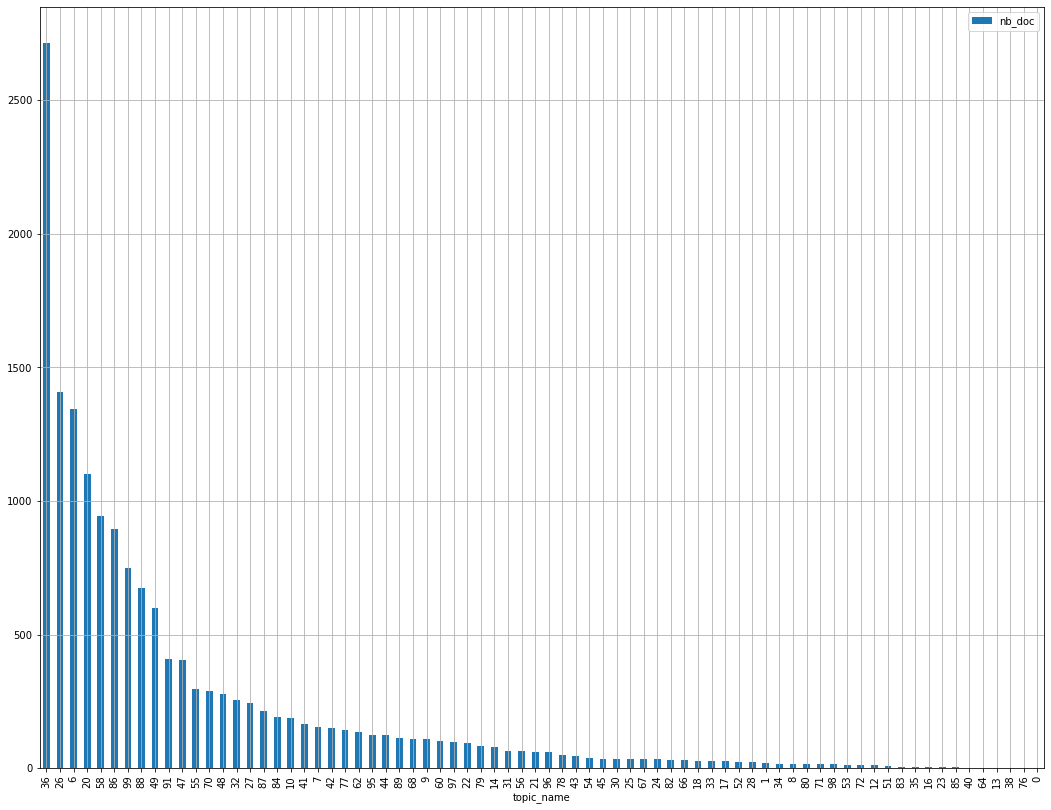

In [184]:
plt.figure()
df_topic_distribution.plot.bar(x='topic_name',y='nb_doc',figsize=(18,14))
plt.grid()
plt.show()

In [166]:
lda.n_components

100

In [169]:
len(X_train)

12712

### Etudes avec l'entrée de type TF-IDF

On va réaliser la même étude avec une entrée de type TF-IDF, suivi par une LDA. Par la suite, on pourra comparer la catégorisation réalisée par les LDA avec celles des tags en supervisé.

In [28]:

X_train_trf = pipe_tfidf_input_lda_cv.best_estimator_[0].fit_transform(X_train) # data_vectorized
lda = pipe_tfidf_input_lda_cv.best_estimator_[1]

# Log Likelihood: Higher the better
print("Log Likelihood: ", lda.score( X_train_trf))

# Perplexity: Lower the better. Perplexity = exp(-1. * log-likelihood per word)
print("Perplexity: ",  lda.perplexity(X_train_trf ))


Log Likelihood:  -647047.597160002
Perplexity:  17665.48030740677


On peut évaluer une partie de la classification des mots dans certains topics comme ceci:

In [24]:
no_top_words = 10
tfidf_input_feature_names = pipe_tfidf_input_lda_cv.best_estimator_[0].get_feature_names() # ou pipe_cvect_input_lda_cv
display_topics(lda, tfidf_input_feature_names, no_top_words)


Topic 0:
port vagrant webservice localhost forwarded host guest ruby config firewall
Topic 1:
tests sharedinstance flip guideline applies occasionally market multipart somebody openconnection
Topic 2:
rounded corners cell collectionview indexpath tableview uicollectionview nsindexpath cgsize layout
Topic 3:
apple circle assign red list banana array yellow colour operator
Topic 4:
alignment gesture anaconda unpack right left zsh gpus bash subclassing
Topic 5:
std bind lambdas scheduling chunk recent kernel linux extern attack
Topic 6:
label stack alt view screen let shortcuts word line master
Topic 7:
authorization arraylist items vba dateformat codes getint elegant anymore iphonesimulator
Topic 8:
broker nullable true single less given string solution must price
Topic 9:
slave deps drawerlayout toolbar mode drawer lock closed unlocked msg
Topic 10:
scrolltop imply four pid investigation oncreate sdcard imagemagick subplot deleted
Topic 11:
designed preprocessing iterable unauthorized r

On va visualiser les topics de pyLDAvis pour le nombre 100:

In [63]:
pyLDAvis.enable_notebook()
tfidf_panel = pyLDAvis.sklearn.prepare(lda, X_train_trf ,  pipe_tfidf_input_lda_cv.best_estimator_[0], mds='tsne')
tfidf_panel

C:\Users\daims\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\daims\AppData\Roaming\Python\Python38\site-packages\pyLDAvis\_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info = default_term_info.sort_values(
C:\Users\daims\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\daims\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\daims\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:819:

PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
78     30.018909 -66.592804       1        1  77.937239
56    -49.862175 -49.630985       2        1   3.587084
14     46.062103  50.099052       3        1   1.529286
98    -26.736595 -68.083267       4        1   1.137405
25    -38.689800  54.688862       5        1   0.431099
...          ...        ...     ...      ...        ...
34    -41.579208  18.692366      96        1   0.159221
33    -17.736605  27.242470      97        1   0.159221
32     14.573684   4.848612      98        1   0.159221
31     -8.457290  19.229433      99        1   0.159221
99      1.752307  14.920693     100        1   0.159221

[100 rows x 5 columns], topic_info=            Term        Freq       Total  Category  logprob  loglift
256      android  148.000000  148.000000   Default  30.0000  30.0000
4731      python  115.000000  115.000000   Default  29.0000  29.0000
3974        node   69.000000   69.000000   Default  28.0000  28.0000
3949         new  167.000000  167.000000   Default  27.0000  27.0000
4698      public  137.000000  137.000000   Default  26.0000  26.0000
...          ...         ...         ...       ...      ...      ...
4467     polling    0.015409    5.482309  Topic100  -8.8301   0.5683
2369         foo    0.015409   51.768216  Topic100  -8.8301  -1.6769
3276        june    0.015409    2.632085  Topic100  -8.8301   1.3021
5185         row    0.015409   36.384650  Topic100  -8.8301  -1.3243
1650  developing    0.015409   11.229552  Topic100  -8.8301  -0.1487

[6150 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
8         1  0.900885          10
13        1  0.890028          11
14        1  0.640680          12
15        1  0.637051          13
16        1  0.763134          14
...     ...       ...         ...
6827      1  0.613184        zend
6830      1  0.882649         zip
6833      1  0.816214        zone
6837      1  0.831789         zsh
6838      3  0.652404  zygoteinit

[2428 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[79, 57, 15, 99, 26, 65, 14, 40, 3, 27, 59, 37, 74, 41, 66, 80, 97, 10, 58, 67, 71, 70, 94, 95, 69, 68, 96, 98, 88, 64, 63, 62, 61, 60, 89, 72, 73, 93, 87, 86, 85, 84, 83, 82, 81, 90, 91, 56, 92, 78, 77, 76, 75, 1, 51, 55, 29, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 13, 12, 11, 9, 8, 7, 6, 5, 4, 28, 30, 54, 31, 53, 52, 2, 50, 49, 48, 47, 46, 45, 44, 43, 42, 39, 38, 36, 35, 34, 33, 32, 100])

  
Visualisons ces topics par des histogrammes.

In [ ]:
# fit(X, y=None, *, groups=None, **fit_params)

In [31]:
X_train_trf.shape

(12712, 6839)

In [43]:
Y_pred = pipe_cvect_input_lda_cv.best_estimator_.transform(X_train)
Y_pred

array([[1.40845070e-04, 1.40845070e-04, 1.40845070e-04, ...,
        1.40845070e-04, 1.40845070e-04, 1.40845070e-04],
       [1.33333333e-04, 1.33333333e-04, 1.33333333e-04, ...,
        1.33333333e-04, 1.33333333e-04, 1.33333333e-04],
       [8.06451613e-05, 8.06451613e-05, 8.06451613e-05, ...,
        8.06451613e-05, 8.06451613e-05, 8.06451613e-05],
       ...,
       [1.61290323e-04, 1.61290323e-04, 1.61290323e-04, ...,
        1.61290323e-04, 1.61290323e-04, 1.61290323e-04],
       [1.64536230e-02, 1.33333333e-04, 1.33333333e-04, ...,
        1.33333333e-04, 1.33333333e-04, 1.33333333e-04],
       [1.69491525e-04, 1.69491525e-04, 1.69491525e-04, ...,
        1.69491525e-04, 1.69491525e-04, 1.69491525e-04]])

In [45]:
Y_pred.shape

(12712, 100)

In [46]:
Y_pred[0]

array([1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.46811732e-02, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 2.65311901e-02, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 5.10899459e-01, 3.87991892e-02, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       2.46210795e-02, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 4.94648979e-02, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
      

In [47]:
len(X_train)

12712

In [48]:
# column names
topicnames = ["topic_" + str(i) for i in range(1,lda.n_components+1)]

# index names
docnames = ["doc_" + str(i) for i in range(len(X_train))]

# Make the pandas dataframe
df_doc_topic_tfidf = pd.DataFrame(np.round(Y_pred, 2), columns=topicnames, index=docnames)

# Get dominant topic for each document
dominant_topic = np.argmax(df_doc_topic_tfidf.values, axis=1)
df_doc_topic_tfidf['dominant_topic'] = dominant_topic


In [49]:
df_doc_topic_tfidf

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,...,topic_92,topic_93,topic_94,topic_95,topic_96,topic_97,topic_98,topic_99,topic_100,dominant_topic
doc_0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.01,...,0.0,0.00,0.00,0.12,0.00,0.0,0.0,0.0,0.00,29
doc_1,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.24,0.0,0.01,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,54
doc_2,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.93,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,7
doc_3,0.00,0.0,0.0,0.09,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,54
doc_4,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.41,0.00,0.00,0.00,0.0,0.0,0.0,0.00,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
doc_12707,0.00,0.0,0.0,0.00,0.0,0.0,0.03,0.00,0.0,0.00,...,0.0,0.00,0.04,0.00,0.00,0.0,0.0,0.0,0.02,85
doc_12708,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,78
doc_12709,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,14
doc_12710,0.02,0.0,0.0,0.00,0.0,0.0,0.00,0.16,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,78


In [51]:
df_doc_topic_tfidf_distribution = df_doc_topic_tfidf['dominant_topic'].value_counts().reset_index(name="nb_doc")
df_doc_topic_tfidf_distribution.columns = ['topic_name', 'nb_doc']
df_doc_topic_tfidf_distribution

,topic_name,nb_doc
0,64,3306
1,78,1856
2,85,740
3,7,627
4,32,520
...,...,...
61,92,1
62,21,1
63,16,1
64,34,1


On trace ici la distribution des documents associés à un topic dominant.

<Figure size 432x288 with 0 Axes>

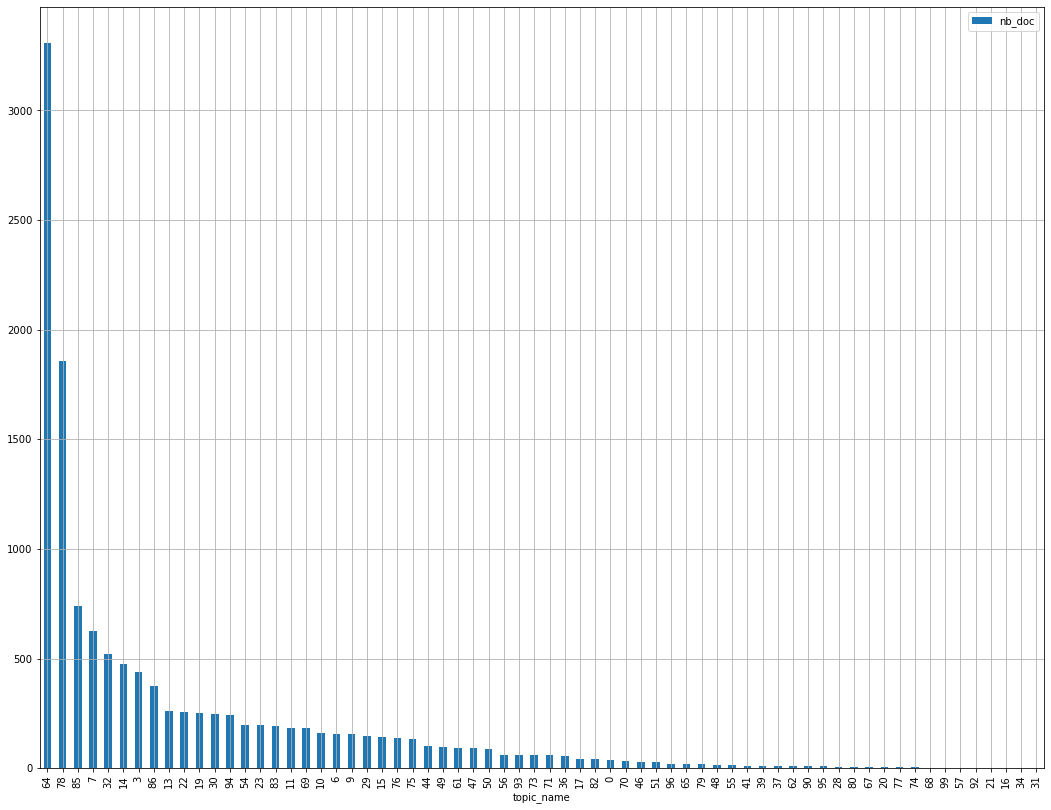

In [52]:
plt.figure()
df_doc_topic_tfidf_distribution.plot.bar(x='topic_name',y='nb_doc',figsize=(18,14))
plt.grid()
plt.show()

In [53]:
lda.n_components

100

In [54]:
len(X_train)

12712

On réalisera une étude plus spécifique sur la LDA, ainsi que les autres approches de type supervisées dans un notebook de synthèse où il sera plus facile de charger les modèles entraînés.